In [1]:
import nltk
import spacy
import pandas as pd
import textstat
import re
from nltk.corpus import state_union
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.api as sm
import numpy as np
from collections import defaultdict
from pathlib import Path

nltk.download('state_union')
# !python -m spacy download en_core_web_sm 
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package state_union to
[nltk_data]     /Users/tiloftus/nltk_data...
[nltk_data]   Package state_union is already up-to-date!


In [2]:
merged_nltk = defaultdict(str)

for fileid in state_union.fileids():
    base = re.sub(r"-\d+\.txt", ".txt", fileid)
    merged_nltk[base] += "\n" + state_union.raw(fileid)

In [3]:
all_texts = []

# NLTK (now correctly merged)
for filename, text in merged_nltk.items():
    all_texts.append((filename, text))

# APP local files
folder = Path("speeches")
for file in folder.glob("*.txt"):
    all_texts.append((file.name, file.read_text(encoding="utf-8")))

In [4]:
def get_clause_heads(doc):
    return [t for t in doc if t.pos_ == "VERB" and t.dep_ in ("ROOT","advcl","ccomp","xcomp","relcl")]

def get_t_units(doc):
    return [t for t in doc if t.pos_ == "VERB" and t.dep_ == "ROOT"]

def get_coordinate_phrases(doc):
    return [t for t in doc if t.dep_ == "conj"]

def get_complex_nominals(doc):
    nominals = []
    for token in doc:
        if token.pos_ in ("NOUN","PROPN"):
            mods = [c for c in token.children if c.dep_ in ("amod","compound","nmod","poss","appos","acl")]
            if mods:
                nominals.append(token)
    return nominals

def mean_sentence_length(doc):
    sents = list(doc.sents)
    return sum(len(s) for s in sents) / len(sents)

def clauses_per_sentence(doc):
    return len(get_clause_heads(doc)) / len(list(doc.sents))

def subordinate_clauses(doc):
    subs = [t for t in doc if t.dep_ in ("advcl","ccomp","xcomp","relcl")]
    return len(subs) / len(list(doc.sents))

def tree_depth(token):
    if not list(token.children):
        return 1
    return 1 + max(tree_depth(c) for c in token.children)

def avg_tree_depth(doc):
    return sum(tree_depth(sent.root) for sent in doc.sents) / len(list(doc.sents))

def mean_length_t_unit(doc):
    t_units = get_t_units(doc)
    if not t_units:
        return 0
    return sum(len(list(t.subtree)) for t in t_units) / len(t_units)

def clauses_per_t_unit(doc):
    t_units = get_t_units(doc)
    if not t_units:
        return 0
    return len(get_clause_heads(doc)) / len(t_units)

def complex_t_units_ratio(doc):
    t_units = get_t_units(doc)
    if not t_units:
        return 0
    complex_count = 0
    for t in t_units:
        if any(tok.dep_ in ("advcl","ccomp","xcomp","relcl") for tok in t.subtree):
            complex_count += 1
    return complex_count / len(t_units)

def coord_phrases_per_clause(doc):
    clauses = get_clause_heads(doc)
    if not clauses:
        return 0
    return len(get_coordinate_phrases(doc)) / len(clauses)

def complex_nominals_per_clause(doc):
    clauses = get_clause_heads(doc)
    if not clauses:
        return 0
    return len(get_complex_nominals(doc)) / len(clauses)

In [5]:
results = []

for filename, text in all_texts:
    text = re.sub(r"\[.*?\]", "", text)
    doc = nlp(text)

    match = re.search(r"(\d{4})-(.+)\.txt", filename)
    if not match:
        continue

    year = int(match.group(1))
    president = match.group(2)

    results.append({
        "year": year,
        "president": president,
        "file": filename,
        "fk_grade": textstat.flesch_kincaid_grade(text),
        "mean_sent_len": mean_sentence_length(doc),
        "clauses_per_sent": clauses_per_sentence(doc),
        "sub_clauses": subordinate_clauses(doc),
        "tree_depth": avg_tree_depth(doc),
        "MLT": mean_length_t_unit(doc),
        "C_per_T": clauses_per_t_unit(doc),
        "CT_per_T": complex_t_units_ratio(doc),
        "CP_per_C": coord_phrases_per_clause(doc),
        "CN_per_C": complex_nominals_per_clause(doc),
    })

In [6]:
df = pd.DataFrame(results).sort_values("year")
print(df.head())
print("Total speeches:", len(df))

     year  president                file   fk_grade  mean_sent_len  \
68   1901  Roosevelt  1901-Roosevelt.txt  14.628106      31.679356   
73   1902  Roosevelt  1902-Roosevelt.txt  14.892697      32.524096   
106  1903  Roosevelt  1903-Roosevelt.txt  15.212138      33.704453   
124  1904  Roosevelt  1904-Roosevelt.txt  16.279796      36.150094   
64   1905  Roosevelt  1905-Roosevelt.txt  15.709415      34.423029   

     clauses_per_sent  sub_clauses  tree_depth        MLT   C_per_T  CT_per_T  \
68           1.830161     1.484627    8.185944  32.601831  2.860412  0.686499   
73           1.960843     1.578313    8.168675  31.880531  2.880531  0.681416   
106          1.746964     1.285425    8.054656  36.447130  2.607251  0.643505   
124          2.026266     1.682927    8.570356  36.209366  2.975207  0.655647   
64           2.012516     1.687109    8.311640  34.400756  3.039698  0.710775   

     CP_per_C  CN_per_C  
68   0.686400  1.675200  
73   0.594470  1.543779  
106  0.772885 

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

features = [
    "fk_grade",
    "mean_sent_len",
    "clauses_per_sent",
    "sub_clauses",
    "tree_depth",
    "MLT",
    "C_per_T",
    "CT_per_T",
    "CP_per_C",
    "CN_per_C"
]

X = df[features]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

df["PC1"] = pcs[:,0]
df["PC2"] = pcs[:,1]

print(pca.explained_variance_ratio_)
print(pca.components_)

X = sm.add_constant(df["year"])
y = df["PC1"]

sm.OLS(y, X).fit().summary()

[0.62376922 0.29483576]
[[ 0.35067611  0.39042638  0.29391534  0.33022092  0.37059696  0.38589036
   0.33369961  0.23918545  0.22849677  0.14876849]
 [ 0.25667423  0.10713367 -0.36085657 -0.31816575  0.15361713  0.10903845
  -0.27875217 -0.3930981   0.39615019  0.51627738]]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    PC1   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     128.3
Date:                Fri, 08 May 2026   Prob (F-statistic):           8.31e-21
Time:                        16:57:04   Log-Likelihood:                -247.14
No. Observations:                 125   AIC:                             498.3
Df Residuals:                     123   BIC:                             503.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         96.2753      8.502     11.323      0.000      79.446     113.105
year          -0.0490      0.004    -11.325      0.000      -0.058      -0.040
==============================================================================
Omnibus:                        2.087   Durbin-Watson:                   1.042
Prob(Omnibus):                  0.352   Jarque-Bera (JB):                1.575
Skew:                           0.192   Prob(JB):                        0.455
Kurtosis:                       3.393   Cond. No.                     1.06e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.06e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

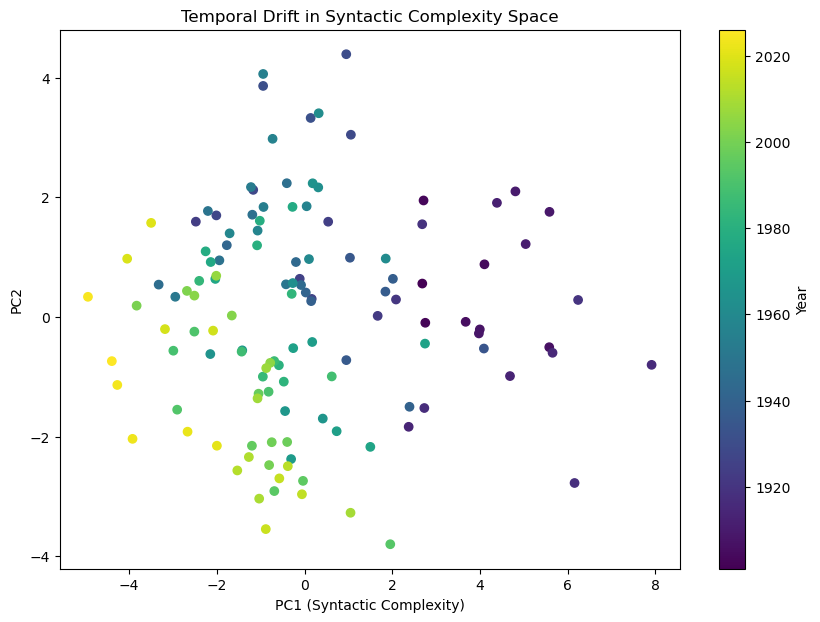

In [8]:
plt.figure(figsize=(10,7))
sc = plt.scatter(df["PC1"], df["PC2"], c=df["year"])
plt.colorbar(sc, label="Year")
plt.xlabel("PC1 (Syntactic Complexity)")
plt.ylabel("PC2")
plt.title("Temporal Drift in Syntactic Complexity Space")
plt.show()

In [9]:
import pandas as pd
pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=["PC1", "PC2"]
)

,PC1,PC2
fk_grade,0.350676,0.256674
mean_sent_len,0.390426,0.107134
clauses_per_sent,0.293915,-0.360857
sub_clauses,0.330221,-0.318166
tree_depth,0.370597,0.153617
MLT,0.385890,0.109038
C_per_T,0.333700,-0.278752
CT_per_T,0.239185,-0.393098
CP_per_C,0.228497,0.396150
CN_per_C,0.148768,0.516277


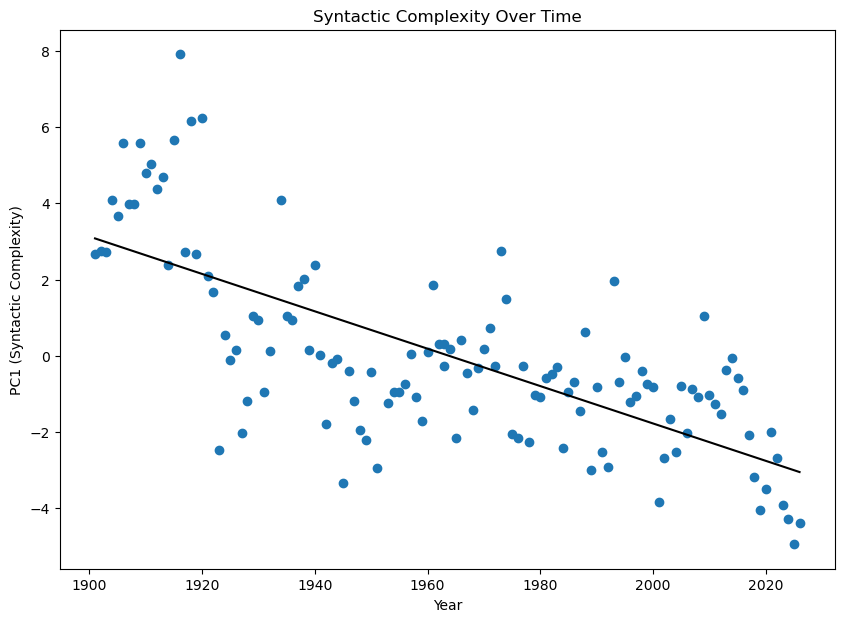

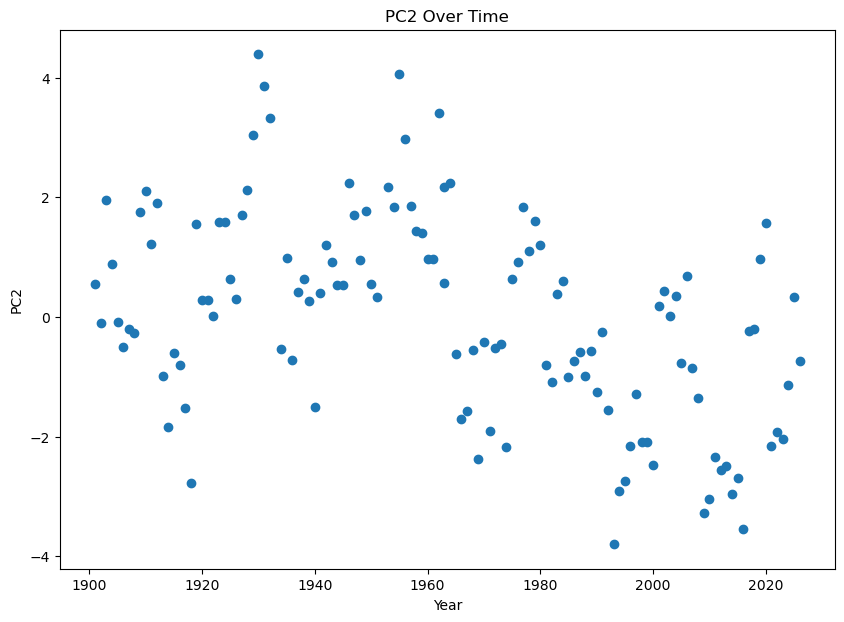

In [10]:
plt.figure(figsize=(10,7))
sc = plt.scatter(df["year"], df["PC1"])

m, b = np.polyfit(df["year"], df["PC1"], 1)
plt.plot(df["year"], m * df["year"] + b, color="black", label="Best Fit Line")

plt.xlabel("Year")
plt.ylabel("PC1 (Syntactic Complexity)")
plt.title("Syntactic Complexity Over Time")
plt.show()

plt.figure(figsize=(10,7))
sc = plt.scatter(df["year"], df["PC2"])
plt.xlabel("Year")
plt.ylabel("PC2")
plt.title("PC2 Over Time")
plt.show()

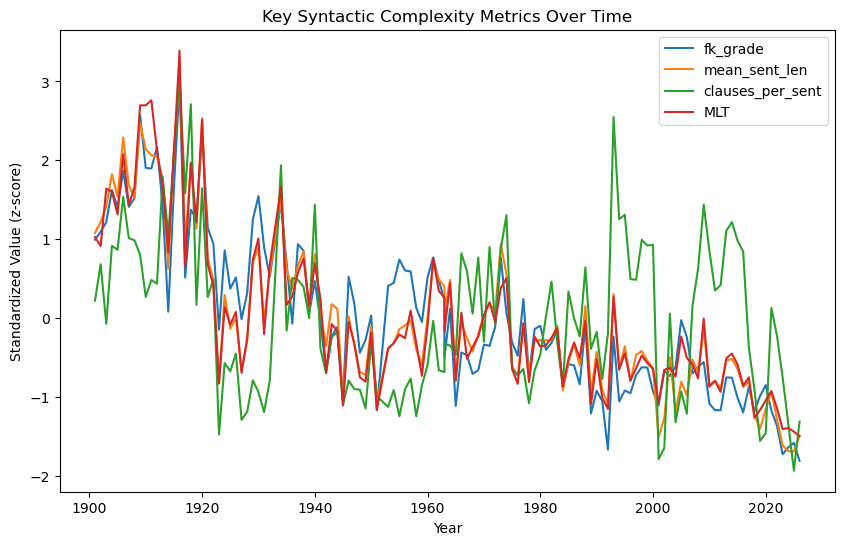

In [11]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Choose 4 most recognizable metrics
plot_metrics = [
    "fk_grade",
    "mean_sent_len",
    "clauses_per_sent",
    "MLT"
]

# Standardize for visual comparison
scaler = StandardScaler()
scaled_vals = scaler.fit_transform(df[plot_metrics])

scaled_df = df.copy()
scaled_df[plot_metrics] = scaled_vals

# Sort by year just in case
scaled_df = scaled_df.sort_values("year")

# Plot
plt.figure(figsize=(10,6))

for metric in plot_metrics:
    plt.plot(scaled_df["year"], scaled_df[metric], label=metric)

plt.xlabel("Year")
plt.ylabel("Standardized Value (z-score)")
plt.title("Key Syntactic Complexity Metrics Over Time")
plt.legend()
plt.show()

In [12]:
# add random intercept for each preseident

import statsmodels.formula.api as smf

model_ri = smf.mixedlm(
    "PC1 ~ year",
    data=df,
    groups=df["president"]
)
result_ri = model_ri.fit()
print(result_ri.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: PC1      
No. Observations: 125     Method:             REML     
No. Groups:       21      Scale:              1.2678   
Min. group size:  2       Log-Likelihood:     -218.6696
Max. group size:  11      Converged:          Yes      
Mean group size:  6.0                                  
-------------------------------------------------------
            Coef.  Std.Err.   z    P>|z| [0.025  0.975]
-------------------------------------------------------
Intercept  100.155   17.170  5.833 0.000 66.502 133.809
year        -0.051    0.009 -5.838 0.000 -0.068  -0.034
Group Var    1.916    0.665                            



In [14]:
rows = []

for filename, text in all_texts:
    # remove bracketed stage directions like before
    text = re.sub(r"\[.*?\]", "", text)

    words = re.findall(r"\b\w+\b", text)
    num_words = len(words)
    num_chars = sum(len(w) for w in words)

    avg_word_len = num_chars / num_words if num_words else 0

    rows.append({
        "file": filename,
        "avg_word_length": avg_word_len,
        "num_words": num_words
    })

df_wordlen = pd.DataFrame(rows)

df_wordlen["avg_word_length"].mean()

df_wordlen["year"] = df_wordlen["file"].str.extract(r"(\d{4})").astype(int)
df_wordlen.sort_values("year")

df_wordlen["num_words"].sum()

916097